In [1]:
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

In [2]:
tickers = ["TSLA", "SPY", "BND"]

frames = []

for ticker in tickers:

    temp = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-06-30",
        auto_adjust=False
    )

    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = temp.columns.get_level_values(0)

    temp = temp.reset_index()

    temp["Ticker"] = ticker

    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
print(df.head())

print(df.columns)

print(type(df.columns))

Price       Date  Adj Close      Close       High        Low       Open  \
0     2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000   
1     2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333   
2     2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000   
3     2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333   
4     2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333   

Price    Volume Ticker  
0      71466000   TSLA  
1      80527500   TSLA  
2      93928500   TSLA  
3      44526000   TSLA  
4      51637500   TSLA  
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='str', name='Price')
<class 'pandas.Index'>


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8664 entries, 0 to 8663
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       8664 non-null   datetime64[s]
 1   Adj Close  8664 non-null   float64      
 2   Close      8664 non-null   float64      
 3   High       8664 non-null   float64      
 4   Low        8664 non-null   float64      
 5   Open       8664 non-null   float64      
 6   Volume     8664 non-null   int64        
 7   Ticker     8664 non-null   str          
dtypes: datetime64[s](1), float64(5), int64(1), str(1)
memory usage: 541.6 KB


Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df["Close"] = pd.to_numeric(df["Close"])

df = df.sort_values(["Ticker", "Date"])

Daily Returns

In [6]:
df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()

Remove missing values

In [7]:
df = df.dropna().reset_index(drop=True)

In [8]:
df.head()

df["Ticker"].value_counts()

Ticker
BND     2887
SPY     2887
TSLA    2887
Name: count, dtype: int64

Save cleaned dataset

In [9]:
df.to_csv("../data/processed/clean_stock_data.csv", index=False)

EDA

Price Trends

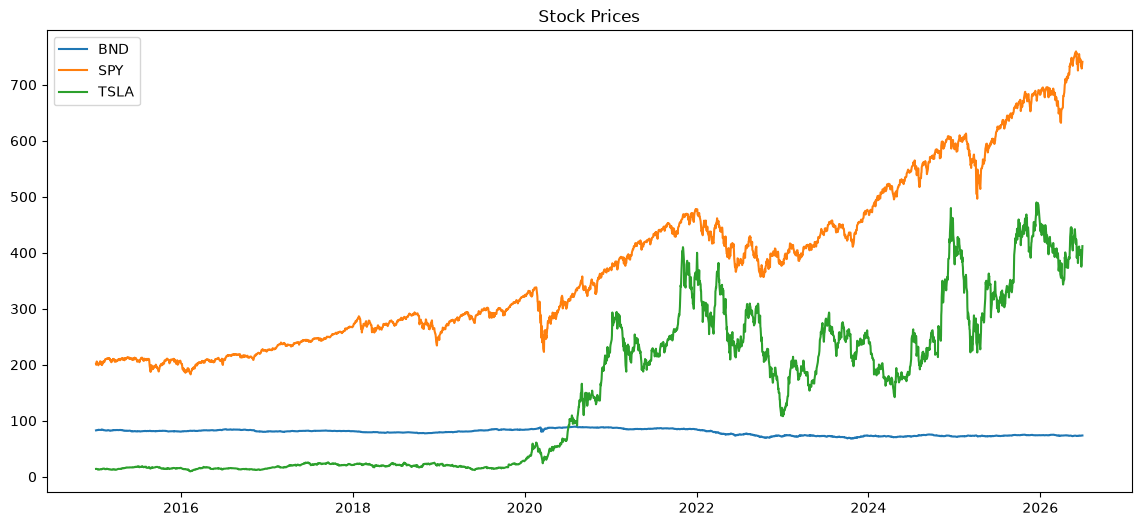

In [10]:
plt.figure(figsize=(14,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(temp["Date"], temp["Close"], label=ticker)

plt.legend()

plt.title("Stock Prices")

plt.show()

Daily Returns

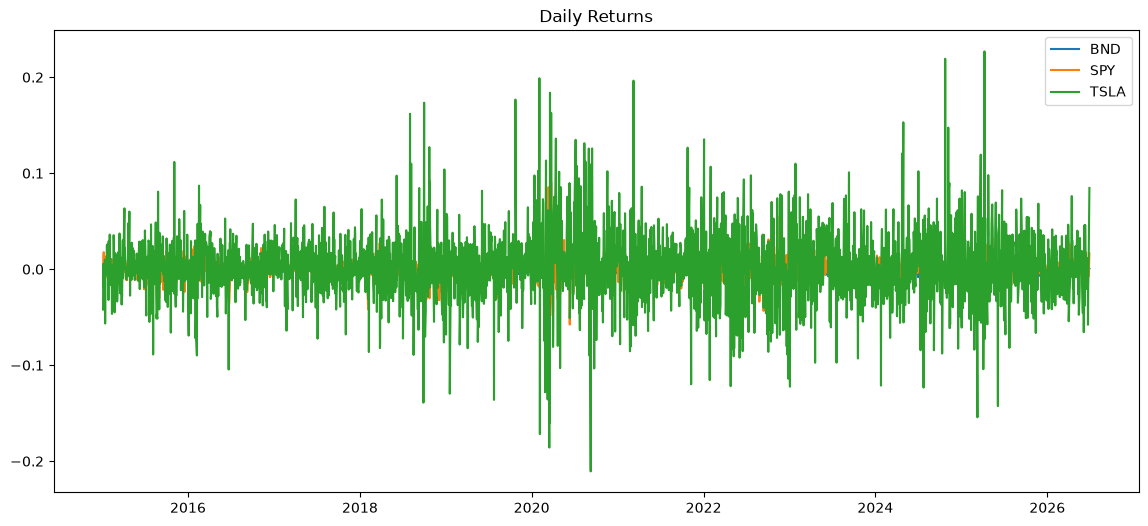

In [11]:
plt.figure(figsize=(14,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(temp["Date"], temp["Daily_Return"], label=ticker)

plt.legend()

plt.title("Daily Returns")

plt.show()

Return Distribution

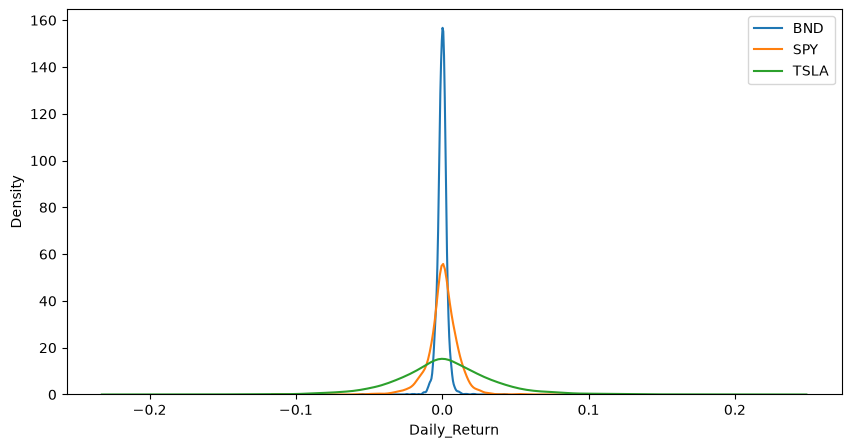

In [12]:
plt.figure(figsize=(10,5))

for ticker in df["Ticker"].unique():

    sns.kdeplot(
        df[df["Ticker"] == ticker]["Daily_Return"],
        label=ticker
    )

plt.legend()

plt.show()

Boxplot

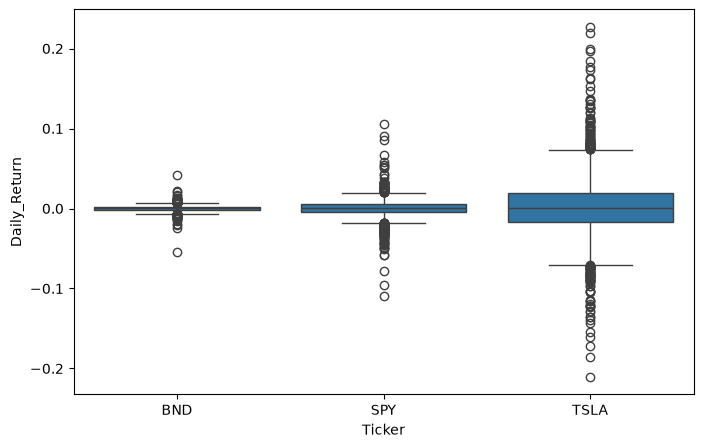

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Ticker", y="Daily_Return")

plt.show()

Correlation Matrix

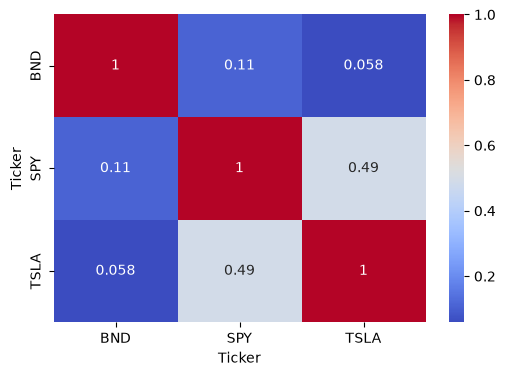

In [14]:
pivot = df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Daily_Return"
)

corr = pivot.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

Cumulative Returns

In [15]:
df["Cumulative_Return"] = (
    1 + df["Daily_Return"]
).groupby(df["Ticker"]).cumprod()

Plot Cumulative Returns

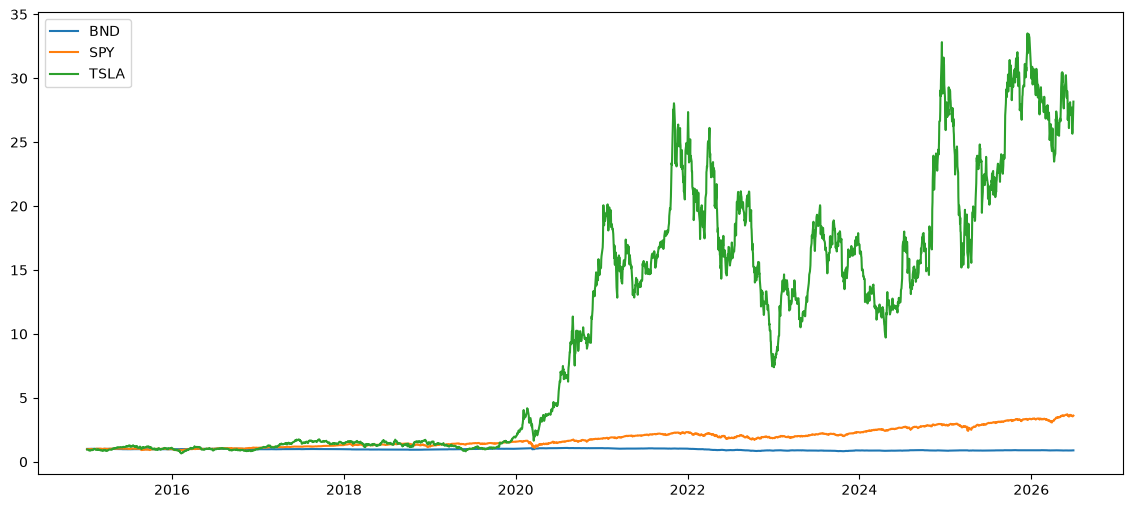

In [16]:
plt.figure(figsize=(14,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(
        temp["Date"],
        temp["Cumulative_Return"],
        label=ticker
    )

plt.legend()

plt.show()

ADF Test

In [17]:
def adf(series):

    result = adfuller(series)

    print("ADF:", result[0])

    print("p-value:", result[1])

    print()

In [18]:
for ticker in df["Ticker"].unique():

    print(ticker)

    adf(
        df[df["Ticker"] == ticker]["Daily_Return"].dropna()
    )

BND
ADF: -15.296417042533234
p-value: 4.372138985795787e-28

SPY
ADF: -17.49053784779802
p-value: 4.4393591670966104e-30

TSLA
ADF: -53.97189280425143
p-value: 0.0



for ticker in df["Ticker"].unique():

    print(ticker)

    adf(
        df[df["Ticker"] == ticker]["Daily_Return"].dropna()
    )

Portfolio Statistics

In [19]:
annual_return = (
    df.groupby("Ticker")["Daily_Return"].mean()
    *252
)

annual_volatility = (
    df.groupby("Ticker")["Daily_Return"].std()
    *np.sqrt(252)
)

risk_free = 0.02

sharpe = (
    annual_return-risk_free
)/annual_volatility

In [20]:
def max_drawdown(r):

    cumulative = (1+r).cumprod()

    running_max = cumulative.cummax()

    drawdown = (cumulative-running_max)/running_max

    return drawdown.min()

In [21]:
drawdown = (
    df.groupby("Ticker")["Daily_Return"]
    .apply(max_drawdown)
)

In [22]:
summary = pd.DataFrame({

    "Annual Return":annual_return,

    "Volatility":annual_volatility,

    "Sharpe":sharpe,

    "Max Drawdown":drawdown

})

summary

,Annual Return,Volatility,Sharpe,Max Drawdown
Ticker,,,,
BND,-0.008548,0.053697,-0.531649,-0.239607
SPY,0.127746,0.177205,0.608028,-0.341047
TSLA,0.454239,0.571775,0.759458,-0.736322


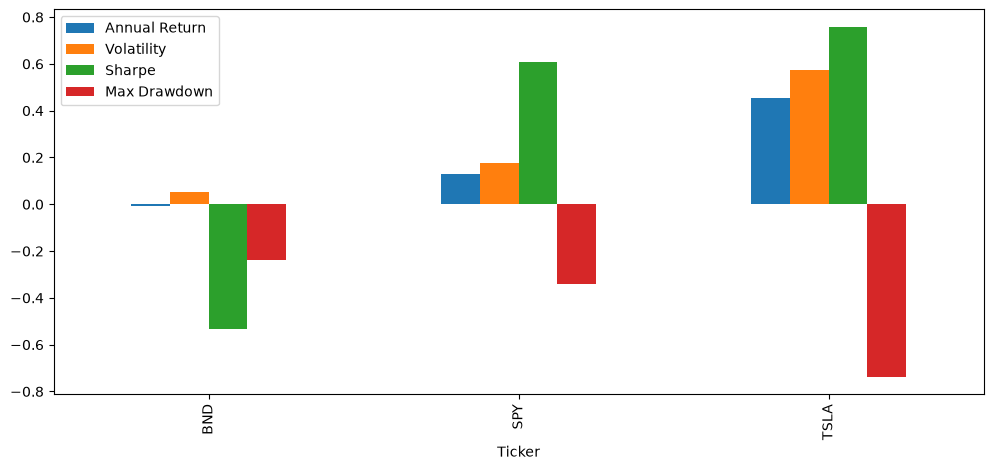

In [23]:
summary.plot(kind="bar", figsize=(12,5))

plt.show()

In [24]:
summary.to_csv(
    "../data/processed/portfolio_summary.csv"
)